<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Reinforcement-learning/blob/main/markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Cadeias de Markov
**Aluno:Thiago Corrêa Brandão(202301135265)**

*Professor: Rodrigo Luna*

In [ ]:
# Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# definição do algoritimo de exponenciação rápida para otimizar os cálculos de exponenciação de matrizes
def exponenciacao_rapida(matriz, expoente):
    if expoente < 0:
        raise ValueError("Expoente precisa ser não negativo")
    if expoente == 0:
        # Retorna matriz identidade do mesmo tamanho
        return np.identity(matriz.shape[0])
    result = np.identity(matriz.shape[0])  # Matriz identidade
    current_power = matriz.copy()
    while expoente > 0:
        # expoente ímpar
        if expoente % 2 == 1:
            result = np.dot(result, current_power)
        # Eleva ao quadrado para a próxima iteração
        current_power = np.dot(current_power, current_power)
        expoente //= 2  # Divide o expoente por 2
    return result

In [ ]:
# Função que define a cadeia de markov(método iterativo)
def markov(pi_zero,matriz_transicao,t,resultados=None,erros=None):
  if resultados is None:
    resultados = []
    erros = []
  p_t = exponenciacao_rapida(matriz_transicao,t)
  if t == 0:
    resultados.append(pi_zero)
    return pi_zero,resultados
  elif t == 1:
    pi_1 = pi_zero
    resultado = np.dot(pi_1,p_t)
    resultados.append(resultado)
    erros.append(np.linalg.norm(pi_1-resultado))
    return resultado,resultados,erros
  else:
    pi_t,resultados,erros = markov(pi_zero,matriz_transicao,t-1)
    resultado = np.dot(pi_t,p_t)
    resultados.append(resultado)
    erros.append(np.linalg.norm(pi_t-resultado))
    return resultado,resultados,erros

In [ ]:
estado_inicial = np.array([0.6,0.4])
matriz_de_transicao = np.array([[0.6,0.4],[0.3,0.7]])
t = 20
resultado,resultados,erros=markov(estado_inicial,matriz_de_transicao,t)
resultado

array([0.42857143, 0.57142857])

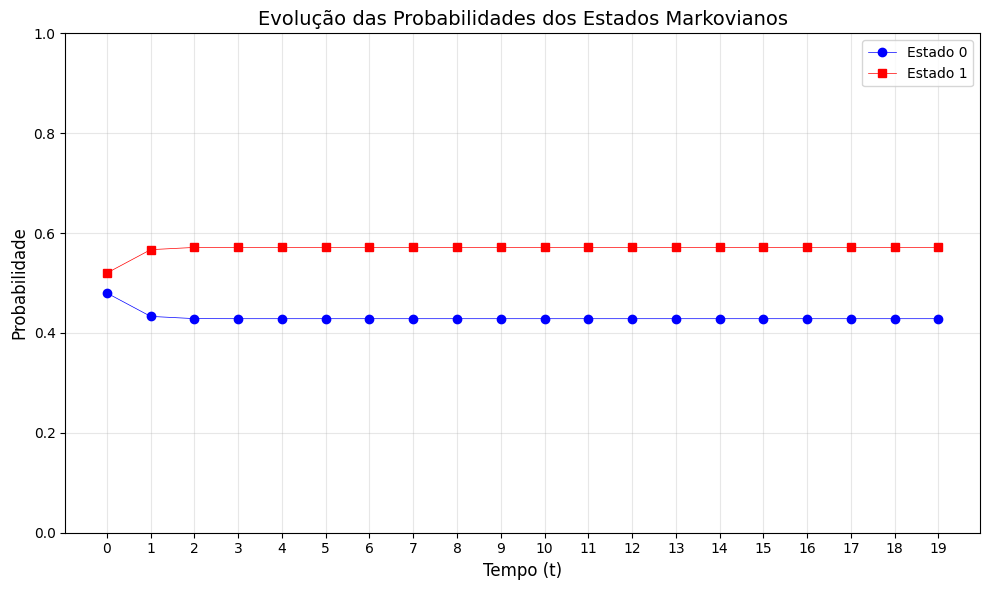

In [ ]:
# Dados
tempos = list(range(len(resultados)))
prob_estado_0 = [resultado[0] for resultado in resultados]
prob_estado_1 = [resultado[1] for resultado in resultados]
# Configuração do gráfico
plt.figure(figsize=(10, 6))
plt.plot(tempos, prob_estado_0, 'b-', marker='o', label='Estado 0', linewidth=0.5)
plt.plot(tempos, prob_estado_1, 'r-', marker='s', label='Estado 1', linewidth=0.5)
# Configurações do gráfico
plt.xlabel('Tempo (t)', fontsize=12)
plt.ylabel('Probabilidade', fontsize=12)
plt.title('Evolução das Probabilidades dos Estados Markovianos', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(tempos)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

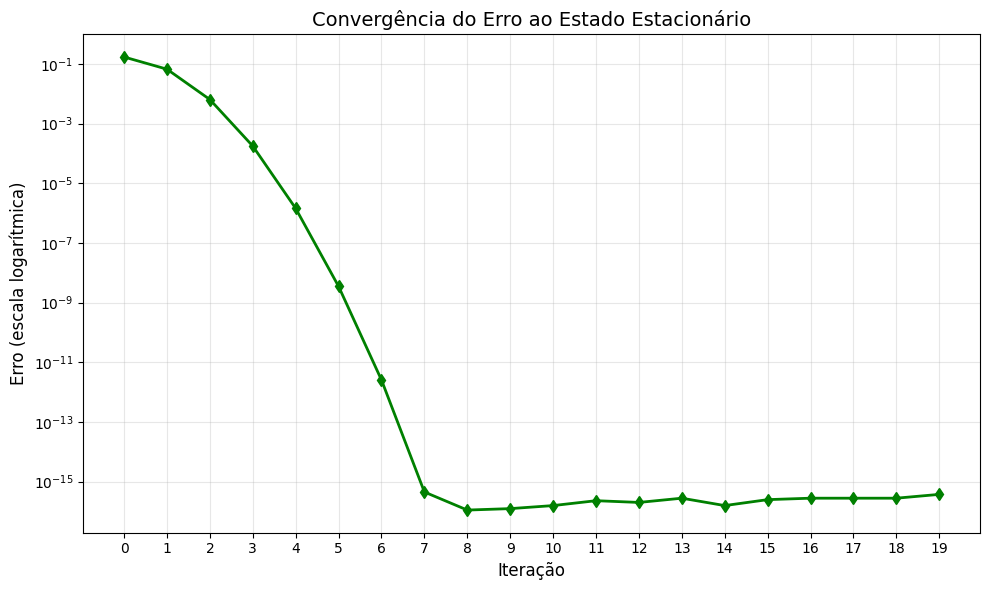

In [ ]:
plt.figure(figsize=(10, 6))

# Plot do erro em escala logarítmica
plt.semilogy(range(len(erros)), erros, 'g-', marker='d', linewidth=2, markersize=6)

# Configurações do gráfico
plt.xlabel('Iteração', fontsize=12)
plt.ylabel('Erro (escala logarítmica)', fontsize=12)
plt.title('Convergência do Erro ao Estado Estacionário', fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.xticks(range(len(erros)))
plt.tight_layout()
plt.show()